In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')

df = pd.read_csv('data_preprocessed.csv')

# Encodage de la cible
df['label_enc'] = (df['label'] == 'spam').astype(int)  # spam=1, ham=0

print(f'Dataset : {df.shape}')
df[['label', 'text_lemmatized', 'label_enc']].head(3)

Dataset : (5572, 10)


,label,text_lemmatized,label_enc
0,ham,go jurong point crazy available bugis great wo...,0
1,ham,ok lar joking wif oni,0
2,spam,free entry wkly comp win fa cup final tkts st ...,1


In [12]:
# ── Train / Test split ──────────────────────────────────────────────────────
# On split UNE FOIS et on réutilise les mêmes indices pour toutes les représentations
X_raw = df['text_lemmatized'].fillna('')
y = df['label_enc']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train_raw)} | Test : {len(X_test_raw)}')
print(f'Proportion spam train : {y_train.mean():.1%}')
print(f'Proportion spam test  : {y_test.mean():.1%}')

Train : 4457 | Test : 1115
Proportion spam train : 13.4%
Proportion spam test  : 13.4%


Bag of Words 

In [13]:
# CountVectorizer = Bag of Words 
bow_vectorizer = CountVectorizer(
    max_features=5000,    # on garde les 5000 mots les plus fréquents
    min_df=2,             # ignore les mots apparaissant < 2 fois
    max_df=0.95,          # ignore les mots dans > 95% des docs (trop communs)
)

X_train_bow = bow_vectorizer.fit_transform(X_train_raw)
X_test_bow  = bow_vectorizer.transform(X_test_raw)

print(f'Taille du vocabulaire BoW : {len(bow_vectorizer.vocabulary_)}')
print(f'Shape X_train_bow : {X_train_bow.shape}  (sparse matrix)')
print(f'Densité : {X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.4%}')
print(f'\nExemple — premiers mots du vocabulaire :')
print(list(bow_vectorizer.vocabulary_.keys())[:20])

Taille du vocabulaire BoW : 2790
Shape X_train_bow : (4457, 2790)  (sparse matrix)
Densité : 0.2613%

Exemple — premiers mots du vocabulaire :
['guy', 'close', 'please', 'come', 'town', 'important', 'moro', 'ok', 'sry', 'knw', 'siva', 'tat', 'askd', 'see', 'yeah', 'swing', 'bit', 'get', 'thing', 'take']


 TF-IDF 

In [14]:
#  TF-IDF Unigrammes 
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,  
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_raw)

print(f'Shape X_train_tfidf : {X_train_tfidf.shape}')

# ── Top mots TF-IDF par classe ───────────────────────────────────────────────
feature_names = tfidf_vectorizer.get_feature_names_out()

for label_val, label_name in [(0, 'HAM'), (1, 'SPAM')]:
    mask = (y_train == label_val).to_numpy()
    mean_scores = X_train_tfidf[mask].mean(axis=0).A1
    top_idx = mean_scores.argsort()[-15:][::-1]
    print(f'\n=== Top 15 features TF-IDF — {label_name} ===')
    print([(feature_names[i], round(mean_scores[i], 4)) for i in top_idx])

Shape X_train_tfidf : (4457, 2790)

=== Top 15 features TF-IDF — HAM ===
[('get', np.float64(0.0265)), ('go', np.float64(0.0227)), ('ok', np.float64(0.0212)), ('come', np.float64(0.0186)), ('call', np.float64(0.0171)), ('gt', np.float64(0.0148)), ('lt', np.float64(0.0146)), ('good', np.float64(0.0139)), ('know', np.float64(0.0135)), ('time', np.float64(0.0129)), ('sorry', np.float64(0.0128)), ('want', np.float64(0.0121)), ('home', np.float64(0.012)), ('later', np.float64(0.012)), ('like', np.float64(0.0116))]

=== Top 15 features TF-IDF — SPAM ===
[('call', np.float64(0.0778)), ('free', np.float64(0.0519)), ('txt', np.float64(0.0409)), ('claim', np.float64(0.0367)), ('mobile', np.float64(0.0348)), ('text', np.float64(0.0345)), ('stop', np.float64(0.0329)), ('reply', np.float64(0.0314)), ('prize', np.float64(0.0297)), ('ur', np.float64(0.0295)), ('service', np.float64(0.0281)), ('cash', np.float64(0.0249)), ('urgent', np.float64(0.0229)), ('new', np.float64(0.0226)), ('min', np.float64(

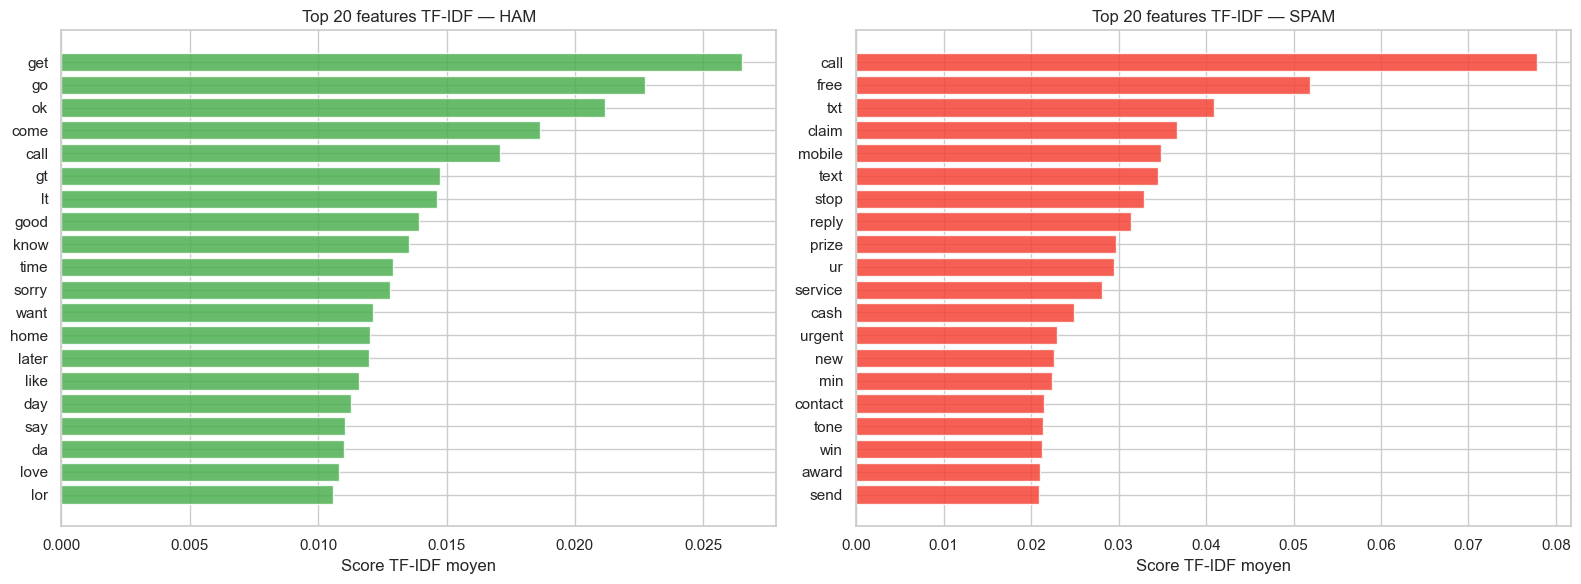

In [15]:
# Visualisation Top features TF-IDF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label_val, label_name, color in [
    (axes[0], 0, 'HAM',  '#4CAF50'),
    (axes[1], 1, 'SPAM', '#F44336')
]:
    mask = (y_train == label_val).to_numpy()
    mean_scores = X_train_tfidf[mask].mean(axis=0).A1
    top_idx = mean_scores.argsort()[-20:][::-1]
    words  = feature_names[top_idx]
    scores = mean_scores[top_idx]
    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top 20 features TF-IDF — {label_name}')
    ax.set_xlabel('Score TF-IDF moyen')

plt.tight_layout()
plt.show()

Bag of N-grams

In [16]:
# ── N-grams : unigrammes + bigrammes + trigrammes ────────────────────────────
configs = {
    'Unigrammes (1,1)':        (1, 1),
    'Bigrammes (2,2)':         (2, 2),
    'Uni+Bi (1,2)':            (1, 2),
    'Uni+Bi+Tri (1,3)':        (1, 3),
}

ngram_vectorizers = {}
ngram_matrices    = {}

for name, ngram_range in configs.items():
    vec = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=10000,
        min_df=2,
        sublinear_tf=True
    )
    X_tr = vec.fit_transform(X_train_raw)
    X_te = vec.transform(X_test_raw)
    ngram_vectorizers[name] = vec
    ngram_matrices[name]    = (X_tr, X_te)
    print(f'{name:<25} → vocab: {len(vec.vocabulary_):>7} features')

Unigrammes (1,1)          → vocab:    2790 features
Bigrammes (2,2)           → vocab:    4256 features
Uni+Bi (1,2)              → vocab:    7046 features
Uni+Bi+Tri (1,3)          → vocab:    9826 features


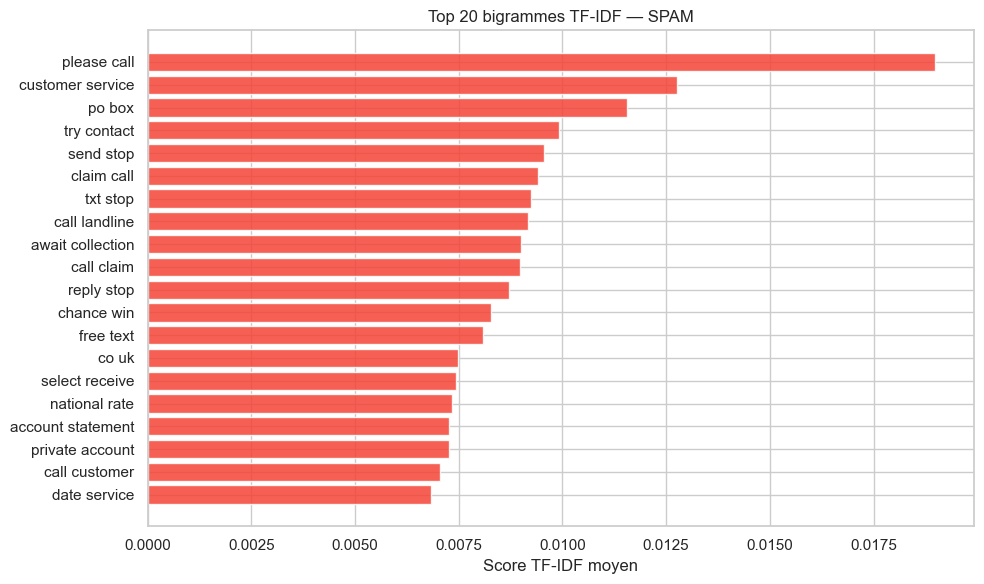

In [17]:
# Top bigrammes SPAM
vec_bi = ngram_vectorizers['Bigrammes (2,2)']
X_bi_train = ngram_matrices['Bigrammes (2,2)'][0]
feature_bi = vec_bi.get_feature_names_out()

mask_spam = (y_train == 1).to_numpy()
mean_bi = X_bi_train[mask_spam].mean(axis=0).A1
top_bi  = mean_bi.argsort()[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_bi[top_bi][::-1], mean_bi[top_bi][::-1], color='#F44336', alpha=0.85)
ax.set_title('Top 20 bigrammes TF-IDF — SPAM')
ax.set_xlabel('Score TF-IDF moyen')
plt.tight_layout()
plt.show()

Sauvegarde des matrices et vectoriseurs

In [18]:
import pickle, scipy.sparse as sp

# Sauvegarder les matrices
sp.save_npz('X_train_bow.npz',   X_train_bow)
sp.save_npz('X_test_bow.npz',    X_test_bow)
sp.save_npz('X_train_tfidf.npz', X_train_tfidf)
sp.save_npz('X_test_tfidf.npz',  X_test_tfidf)

# Sauvegarder les labels
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

# Sauvegarder les matrices N-grams
for name, (X_tr, X_te) in ngram_matrices.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
    sp.save_npz(f'X_train_ngram_{safe_name}.npz', X_tr)
    sp.save_npz(f'X_test_ngram_{safe_name}.npz',  X_te)

# Sauvegarder les vectoriseurs
with open('vectorizers.pkl', 'wb') as f:
    pickle.dump({'bow': bow_vectorizer, 'tfidf': tfidf_vectorizer,
                 'ngrams': ngram_vectorizers}, f)

print('✅ Toutes les matrices sauvegardées')

✅ Toutes les matrices sauvegardées
